## Construcción y Optimización de un Modelo de Riesgo Crediticio

El objetivo de esta sección es construir el dataset que será utilizado en la etapa de modelado del riesgo crediticio.

Partiendo de un dataset previamente limpiado, se realizan transformaciones adicionales para generar variables más informativas que permitan capturar de manera más precisa el comportamiento financiero de los clientes. En particular, se desarrollan procesos de feature engineering, donde se construyen nuevas variables derivadas —principalmente ratios financieros— que reflejan relaciones económicas relevantes como niveles de endeudamiento, capacidad de pago y comportamiento crediticio.

El resultado final de esta etapa será un dataset estructurado y optimizado para modelado, el cual será utilizado posteriormente para estimar los pesos óptimos del modelo de scoring crediticio.

### Definición del Target en el modelo de credit Z-score

El dataset clasifica el riesgo en tres categorías: **Poor**, **Standard** y **Good**. Sin embargo, siguiendo la lógica de modelos tradicionales como el Z-Score de Altman, el enfoque metodológicamente más sólido es construir primero un **modelo binario** y posteriormente segmentar el score continuo en rangos.

Altman no estimaba tres clases directamente; modelaba el riesgo de quiebra en términos binarios y luego definía zonas interpretativas. Bajo esta misma lógica, el problema debe formularse como:


**Definición del target binario**

El target binario se define como:

$$
\begin{cases}
1 & \text{si } Credit\_Score = \text{"Poor"} \\
0 & \text{si } Credit\_Score \in \{\text{"Standard"}, \text{"Good"}\}
\end{cases}
$$

Esto convierte el modelo en un problema clásico de default.


**Segmentación posterior del score**

Una vez estimado el modelo (por ejemplo, logístico) y obtenido un score continuo ($S$), se pueden definir zonas:

$$
\begin{cases}
S < A \rightarrow \text{"Poor"} \\
A \leq S < B \rightarrow \text{"Standard"} \\
S \geq B \rightarrow \text{"Good"}
\end{cases}
$$

donde $A$ y $B$ son los puntos de corte que determinan las categorías.

**Construcción del Score Clásico**

El score se define como:

$$
S_i = \sum_{j=1}^{k} w_j X_{ij}
$$

Donde:

* $w_j$ = pesos generados aleatoriamente
* $X_{ij}$ = variables seleccionadas para el individuo $i$

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, log_loss, confusion_matrix, classification_report)
from scipy.optimize import differential_evolution, dual_annealing
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_model = pd.read_csv("credit_dataset_clean.csv")
df_model.head()

,Customer_ID,Month,Credit_Score,Age,Annual_Income,Monthly_Inhand_Salary,Outstanding_Debt,Credit_History_Months,Monthly_Balance,Amount_invested_monthly,...,Total_EMI_per_month,Num_Bank_Accounts,Num_Credit_Card,Delay_from_due_date,Credit_Utilization_Ratio,Credit_Mix_final,Payment_of_Min_Amount_final,Spending_Level_final,Payment_Size_final,Occupation
0,CUS_0x1000,January,Standard,18.0,30625.94,2706.161667,1562.91,122.0,252.924793,244.750283,...,42.94109,6.0,5.0,62.0,26.612093,0,1,0,2,Lawyer
1,CUS_0x1000,February,Poor,18.0,30625.94,2552.161667,1562.91,123.0,311.542510,176.132567,...,42.94109,6.0,5.0,62.0,29.439759,0,1,1,0,Lawyer
2,CUS_0x1000,March,Poor,18.0,30625.94,2706.161667,1562.91,124.0,368.618557,109.056519,...,42.94109,6.0,5.0,62.0,38.285928,0,1,1,1,Lawyer
3,CUS_0x1000,April,Poor,18.0,30625.94,2706.161667,1562.91,125.0,419.765167,87.909909,...,42.94109,6.0,5.0,64.0,32.843081,0,1,0,0,Lawyer
4,CUS_0x1000,May,Poor,18.0,30625.94,2706.161667,1562.91,126.0,305.840309,191.834767,...,42.94109,6.0,5.0,67.0,32.330508,0,1,0,2,Lawyer


In [3]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Customer_ID                  100000 non-null  object 
 1   Month                        100000 non-null  object 
 2   Credit_Score                 100000 non-null  object 
 3   Age                          100000 non-null  float64
 4   Annual_Income                100000 non-null  float64
 5   Monthly_Inhand_Salary        100000 non-null  float64
 6   Outstanding_Debt             100000 non-null  float64
 7   Credit_History_Months        100000 non-null  float64
 8   Monthly_Balance              100000 non-null  float64
 9   Amount_invested_monthly      100000 non-null  float64
 10  Num_of_Loan                  100000 non-null  float64
 11  Num_of_Delayed_Payment       100000 non-null  float64
 12  Changed_Credit_Limit         100000 non-null  float64
 13  

### Definición de la Variable Objetivo

Para la construcción del modelo de riesgo crediticio es necesario definir una variable objetivo binaria que represente el evento de interés: default crediticio.

La variable original Credit_Score clasifica a los clientes en tres categorías:

- Poor
- Standard
- Good

Con el fin de enfocar el modelo en la identificación de clientes con mayor riesgo, se construye una variable binaria denominada Y_default bajo el siguiente criterio:

| Credit_Score | Y_default | Interpretación |
| ------------ | --------- | -------------- |
| Poor         | 1         | Default        |
| Standard     | 0         | No Default     |
| Good         | 0         | No Default     |

De esta manera, el modelo se enfoca en predecir la probabilidad de default.

### Distribución de la Variable Objetivo

La distribución observada en el dataset es la siguiente:

- No Default (0): 71.0%
- Default (1): 29.0%

Esto implica que:

$$P(Y=1)=0.28998$$

La variable objetivo presenta cierto grado de desbalance, lo cual es común en problemas de riesgo crediticio, donde los eventos de default ocurren con menor frecuencia que los casos de cumplimiento.

No obstante, el desbalance no es extremo, por lo que el modelo puede entrenarse sin necesidad inmediata de técnicas de balanceo.

### Baseline del Modelo

Antes de entrenar un modelo, es útil establecer un baseline de referencia.

Si el modelo predijera siempre la clase mayoritaria (No Default), obtendría una exactitud aproximada de:

- Accuracy baseline=0.71002

Esto significa que cualquier modelo predictivo desarrollado deberá superar este nivel de desempeño para demostrar capacidad predictiva real.

### Exclusión de Variables

Antes de iniciar el proceso de feature engineering, se eliminan ciertas variables que no deben utilizarse en el modelo. Esto se realiza por dos razones principales:

- Evitar data leakage
- Eliminar variables no informativas para la predicción

Las variables excluidas son:

| Variable                       | Motivo                                                              |
| ------------------------------ | ------------------------------------------------------------------- |
| `Month`                        | Identificador temporal sin valor predictivo directo                 |
| `Occupation`                   | Variable categórica de alta cardinalidad no utilizada en esta etapa |
| `Credit_Score`                 | Variable original de la cual se deriva el target                    |
| `Customer_ID`                  | Identificador único del cliente                                     |
| Variables derivadas del target | Evitar *target leakage*                                             |

Eliminar estas variables garantiza que el modelo se entrene únicamente con información disponible antes del evento de default.

In [4]:
df_model["Y_default"] = (
    df_model["Credit_Score"] == "Poor"
).astype(int)

print(df_model["Y_default"].value_counts(normalize=True))

Y_default
0    0.71002
1    0.28998
Name: proportion, dtype: float64


### **Transformación a Ratios**



#### **Problema de escala en modelos lineales**

Cuando se construye un modelo lineal del tipo:

$$
Z = \sum_{j=1}^{k} w_j X_j
$$

las variables con mayor magnitud numérica dominan el resultado, aun cuando no sean más informativas.

Por ejemplo:

* `Annual_Income` puede estar en **millones**
* `Outstanding_Debt` puede estar en **miles**
* `Credit_Mix_final` toma valores entre **0 y 2**

Si no se realiza una transformación estructural:

$$
w_1 \cdot \text{Annual\_Income} \gg w_2 \cdot \text{Credit\_Mix}
$$

Esto genera un sesgo por escala y no por contenido económico.


#### **Por qué NO normalizar directamente**

La estandarización estadística:

$$
X^* = \frac{X - \mu}{\sigma}
$$

depende de la muestra utilizada.

En un entorno financiero real:

* El score debe poder calcularse **directamente** sobre nuevos clientes
* No puede depender de medias ($\mu$) o desviaciones ($\sigma$) del dataset de entrenamiento
* Debe ser **estable fuera de muestra**
* Debe ser **interpretable económicamente**

Por esta razón, en lugar de normalizar, se construyen **ratios financieros estructurales**.

Este es el mismo principio utilizado en el **Altman Z-Score**:

$$
Z = 1.2X_1 + 1.4X_2 + 3.3X_3 + 0.6X_4 + 1.0X_5
$$

donde todas las variables son **proporciones** y no valores absolutos:

| Variable | Definición | Tipo |
|----------|------------|------|
| $X_1$ | Capital de Trabajo / Activos Totales | Ratio |
| $X_2$ | Utilidades Retenidas / Activos Totales | Ratio |
| $X_3$ | EBIT / Activos Totales | Ratio |
| $X_4$ | Valor Mercado Patrimonio / Pasivos Totales | Ratio |
| $X_5$ | Ventas / Activos Totales | Ratio |


#### **Ventajas de usar ratios**

El uso de ratios financieros presenta varias ventajas:

- Eliminan el problema de escala entre variables
- Capturan relaciones económicas relevantes
- Permiten comparar clientes con distintos niveles de ingreso
- No dependen de estadísticas del dataset de entrenamiento
- Mantienen interpretabilidad económica
- Facilitan la transparencia del modelo

#### **Conclusión**

Los ratios financieros transforman el problema de:

$$
\text{Modelo inestable} \rightarrow Z = w_1 \cdot \text{escala\_absoluta}_1 + w_2 \cdot \text{escala\_absoluta}_2
$$

a:

$$
\text{Modelo robusto} \rightarrow Z = w_1 \cdot \text{ratio}_1 + w_2 \cdot \text{ratio}_2
$$

Esta es la base de los modelos de **credit scoring** utilizados en la banca.

In [5]:
eps = 1e-6 
# RATIOS FINANCIEROS

df_model["R1_DTI"] = df_model["Outstanding_Debt"] / (df_model["Annual_Income"] + eps)

df_model["DTI_squared"] = df_model["R1_DTI"] ** 2 #El riesgo no es lineal

df_model["R2_EMI_Burden"] = df_model["Total_EMI_per_month"] / (
    df_model["Monthly_Inhand_Salary"] + eps
)

df_model["R3_Balance_Coverage"] = df_model["Monthly_Balance"] / (
    df_model["Total_EMI_per_month"] + eps
)

df_model["R4_Savings_Rate"] = df_model["Amount_invested_monthly"] / (
    df_model["Monthly_Inhand_Salary"] + eps
)

df_model["R5_Interest_Stress"] = (
    df_model["Interest_Rate"] * df_model["R1_DTI"]
)

df_model["R6_Limit_Shock_Relative"] = df_model["Changed_Credit_Limit"] / (
    df_model["Annual_Income"] + eps
)

df_model["R7_Inquiry_Intensity"] = df_model["Num_Credit_Inquiries"] / (
    df_model["Credit_History_Months"] + eps
)

df_model["R8_Delays_per_Loan"] = df_model["Num_of_Delayed_Payment"] / (
    df_model["Num_of_Loan"] + eps
)

df_model["R9_Debt_per_Card"] = df_model["Outstanding_Debt"] / (
    df_model["Num_Credit_Card"] + eps
)

df_model["R10_Delay_Intensity_Adjusted"] = df_model["Delay_from_due_date"] / (
    df_model["Credit_History_Months"] + eps
)

### **Ratios Construidos**

Sea $\varepsilon = 10^{-6}$ para evitar división por cero.

#### (R1) Debt-to-Income (DTI)

$$
R1 = \frac{Outstanding\_Debt}{Annual\_Income + \varepsilon}
$$

Mide el nivel de endeudamiento estructural del cliente.

#### (R1²) DTI al cuadrado

$$
R1^2 = \left( \frac{Outstanding\_Debt}{Annual\_Income + \varepsilon} \right)^2
$$

**Justificación:** Se incluye el término cuadrático porque la relación entre endeudamiento y riesgo **no es lineal**. A partir de cierto umbral, incrementos en el DTI generan aumentos más que proporcionales en la probabilidad de default, capturando así efectos de convexidad en el riesgo crediticio.

"The relationship between DSTI and probability of default is non-linear, with probability of default responding to increases in DSTI only after a certain threshold" — FMI Working Paper WP/19/182

- https://www.elibrary.imf.org/view/journals/001/2019/182/article-A001-en.xml 

#### (R2) EMI Burden

$$
R2 = \frac{Total\_EMI\_per\_month}{Monthly\_Inhand\_Salary + \varepsilon}
$$

Mide la presión mensual de pagos sobre el ingreso disponible.

#### (R3) Balance Coverage

$$
R3 = \frac{Monthly\_Balance}{Total\_EMI\_per\_month + \varepsilon}
$$

Indica capacidad de cubrir obligaciones con liquidez disponible.

#### (R4) Savings Rate

$$
R4 = \frac{Amount\_invested\_monthly}{Monthly\_Inhand\_Salary + \varepsilon}
$$

Captura comportamiento de ahorro.

#### (R5) Interest Stress

$$
R5 = Interest\_Rate \times R1
$$

Refleja sensibilidad a tasa de interés dada la carga de deuda.

#### (R6) Limit Shock Relative

$$
R6 = \frac{Changed\_Credit\_Limit}{Annual\_Income + \varepsilon}
$$

Captura ajuste del banco proporcional al ingreso.

#### (R7) Inquiry Intensity

$$
R7 = \frac{Num\_Credit\_Inquiries}{Credit\_History\_Months + \varepsilon}
$$

Indica presión por búsqueda de crédito.

#### (R8) Delays per Loan

$$
R8 = \frac{Num\_of\_Delayed\_Payment}{Num\_of\_Loan + \varepsilon}
$$

Mide deterioro relativo en comportamiento de pago.

#### 🔹 (R9) Debt per Credit Card

$$
R9 = \frac{Outstanding\_Debt}{Num\_Credit\_Card + \varepsilon}
$$

Captura concentración de deuda.

#### 🔹 (R10) Delay Intensity Adjusted

$$
R10 = \frac{Delay\_from\_due\_date}{Credit\_History\_Months + \varepsilon}
$$

Evalúa gravedad del retraso relativa a antigüedad.

In [6]:
#Eliminamos las columnas originales con las que creamos los ratios para evitar overfitting y multicolinealidad
drop_cols = [
    # COLUMNAS USADAS EN LOS RATIOS (18 en total)
    "Outstanding_Debt",              # Usada en R1
    "Annual_Income",                  # Usada en R1 y R6
    "Total_EMI_per_month",            # Usada en R2 y R3
    "Monthly_Inhand_Salary",          # Usada en R2 y R4
    "Monthly_Balance",                # Usada en R3
    "Amount_invested_monthly",        # Usada en R4
    "Interest_Rate",                  # Usada en R5
    "Changed_Credit_Limit",           # Usada en R6
    "Num_Credit_Inquiries",           # Usada en R7
    "Credit_History_Months",          # Usada en R7 y R10
    "Num_of_Delayed_Payment",         # Usada en R8
    "Num_of_Loan",                    # Usada en R8
    "Num_Credit_Card",                 # Usada en R9
    "Delay_from_due_date",             # Usada en R10
]

# Verificar que NO estamos eliminando:
# - "Credit_Score" (target original)
# - "Y_default" (target binario)
# - "Month" (para análisis temporal)
# - "Occupation" (para análisis temporal)
# - "Age", "Num_Bank_Accounts", etc. (variables originales no usadas)

df_model = df_model.drop(columns=drop_cols)

In [7]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Customer_ID                   100000 non-null  object 
 1   Month                         100000 non-null  object 
 2   Credit_Score                  100000 non-null  object 
 3   Age                           100000 non-null  float64
 4   Num_Bank_Accounts             100000 non-null  float64
 5   Credit_Utilization_Ratio      100000 non-null  float64
 6   Credit_Mix_final              100000 non-null  int64  
 7   Payment_of_Min_Amount_final   100000 non-null  int64  
 8   Spending_Level_final          100000 non-null  int64  
 9   Payment_Size_final            100000 non-null  int64  
 10  Occupation                    100000 non-null  object 
 11  Y_default                     100000 non-null  int64  
 12  R1_DTI                        100000 non-null

### **Feature Engineering**

#### Selección de Variables con Significancia

Después del feature engineering, se procede a seleccionar el subconjunto de variables que será utilizado en el modelo final de credit scoring.

El objetivo de esta etapa es:

- Eliminar variables estadísticamente no significativas
- Reducir multicolinealidad
- Mantener únicamente variables económicamente interpretables
- Obtener un modelo estable y parsimonioso

Para ello se implementa un procedimiento automático basado en dos criterios simultáneos:

- Significancia estadística
- Correlación entre variables

**Criterios de Selección**

Las variables se evalúan utilizando una regresión logística preliminar con el único propósito de obtener p-values.

Se conservan únicamente variables que cumplan:

- p-value<0.05

De manera marginal se permite:

- p-value<0.06

Esto permite evitar eliminar variables que puedan tener relevancia económica aunque su significancia sea ligeramente inferior al umbral clásico.

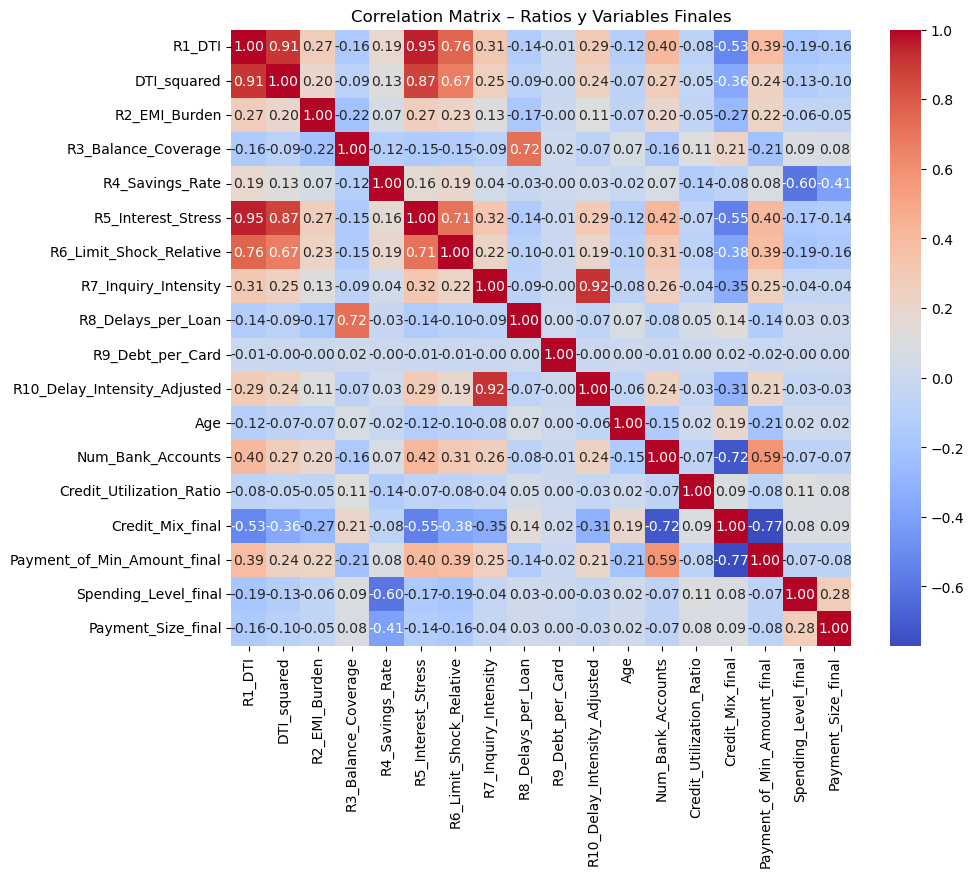

In [8]:
# Debemos revisar la correlación entre las variables que usaremos para predecir el target para evitar multicolinealidad. Si hay alta correlación, podríamos considerar eliminar algunos ratios.
info_cols = [
    # RATIOS CONSTRUIDOS (11 variables)
    "R1_DTI",
    "DTI_squared",
    "R2_EMI_Burden",
    "R3_Balance_Coverage",
    "R4_Savings_Rate",
    "R5_Interest_Stress",
    "R6_Limit_Shock_Relative",
    "R7_Inquiry_Intensity",
    "R8_Delays_per_Loan",
    "R9_Debt_per_Card",
    "R10_Delay_Intensity_Adjusted",
    
    # VARIABLES ORIGINALES NUMÉRICAS (3 variables)
    "Age",
    "Num_Bank_Accounts",
    "Credit_Utilization_Ratio",
    
    # VARIABLES CATEGÓRICAS CODIFICADAS (4 variables)
    "Credit_Mix_final",
    "Payment_of_Min_Amount_final",
    "Spending_Level_final",
    "Payment_Size_final"
]

corr = df_model[info_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix – Ratios y Variables Finales")
plt.show()

In [9]:
def seleccion_final_con_significancia(df, target='Y_default', 
                                       umbral_correlacion=0.7, 
                                       umbral_significancia=0.05,
                                       verbose=True):
    """
    Selección automática que considera:
    1. Correlación entre variables
    2. Significancia estadística (p-valor)
    3. Eliminación cíclica hasta estabilidad
    """
    
    # Inicializar
    variables_actuales = [col for col in df.columns if col != target and col != 'const']
    historial = []
    iteracion = 1
    
    if verbose:
        print("="*80)
        print("SELECCIÓN AUTOMÁTICA CON DOBLE FILTRO")
        print("="*80)
        print(f"Umbral correlación: {umbral_correlacion}")
        print(f"Umbral significancia: {umbral_significancia}")
        print(f"Variables iniciales: {len(variables_actuales)}")
        print("-"*80)
    
    while True:
        if verbose:
            print(f"\n📊 Iteración {iteracion} - Variables: {len(variables_actuales)}")
        
        # PASO 1: Eliminar variables NO significativas del modelo actual
        if len(variables_actuales) > 0:
            X_temp = sm.add_constant(df[variables_actuales].dropna())
            y_temp = df.loc[X_temp.index, target]
            model_temp = sm.Logit(y_temp, X_temp).fit(disp=0)
            
            # Encontrar variables con p-valor > umbral
            p_values = model_temp.pvalues[1:]  # excluir constante
            no_significativas = p_values[p_values > umbral_significancia].index.tolist()
            
            if no_significativas:
                if verbose:
                    print(f"  🔴 Variables NO significativas: {no_significativas}")
                
                # De las no significativas, eliminar la de mayor p-valor
                peor_var = max(no_significativas, key=lambda x: p_values[x])
                
                historial.append({
                    'iteracion': iteracion,
                    'tipo': 'significancia',
                    'variable_eliminada': peor_var,
                    'p_valor': p_values[peor_var],
                    'razon': f'P-valor > {umbral_significancia}'
                })
                
                variables_actuales.remove(peor_var)
                if verbose:
                    print(f"    ❌ Eliminando por baja significancia: {peor_var} (p={p_values[peor_var]:.4f})")
                
                iteracion += 1
                continue  # Revisar significancia antes de correlación
        
        # PASO 2: Verificar correlaciones altas
        corr_matrix = df[variables_actuales].corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr_pairs = [(col, row, upper_tri[col][row]) 
                          for col in upper_tri.columns 
                          for row in upper_tri.index 
                          if upper_tri[col][row] > umbral_correlacion]
        
        if not high_corr_pairs:
            if verbose:
                print("  ✅ No hay más correlaciones altas")
            break
        
        # Ordenar por correlación
        high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
        
        if verbose:
            print(f"  🔍 Pares con correlación alta: {len(high_corr_pairs)}")
        
        variables_a_eliminar = set()
        
        for var1, var2, corr in high_corr_pairs[:5]:  # Procesar top 5
            if var1 in variables_a_eliminar or var2 in variables_a_eliminar:
                continue
            
            # Evaluar ambos modelos individuales
            X1 = sm.add_constant(df[[var1]].dropna())
            y1 = df.loc[X1.index, target]
            model1 = sm.Logit(y1, X1).fit(disp=0)
            auc1 = roc_auc_score(y1, model1.predict(X1))
            
            X2 = sm.add_constant(df[[var2]].dropna())
            y2 = df.loc[X2.index, target]
            model2 = sm.Logit(y2, X2).fit(disp=0)
            auc2 = roc_auc_score(y2, model2.predict(X2))
            
            # Decidir cuál eliminar
            if auc1 >= auc2:
                peor_var = var2
                razon = f"Menor AUC individual ({auc2:.4f} vs {auc1:.4f})"
            else:
                peor_var = var1
                razon = f"Menor AUC individual ({auc1:.4f} vs {auc2:.4f})"
            
            variables_a_eliminar.add(peor_var)
            historial.append({
                'iteracion': iteracion,
                'tipo': 'correlacion',
                'var1': var1,
                'var2': var2,
                'correlacion': corr,
                'auc1': auc1,
                'auc2': auc2,
                'variable_eliminada': peor_var,
                'razon': razon
            })
            
            if verbose:
                print(f"    ❌ Eliminando por correlación: {peor_var}")
                print(f"       {var1}({auc1:.4f}) vs {var2}({auc2:.4f}) - {razon}")
        
        # Eliminar variables
        if variables_a_eliminar:
            variables_actuales = [v for v in variables_actuales if v not in variables_a_eliminar]
        
        iteracion += 1
    
    # ============================================
    # MODELO FINAL
    # ============================================
    X_final = sm.add_constant(df[variables_actuales].dropna())
    y_final = df.loc[X_final.index, target]
    model_final = sm.Logit(y_final, X_final).fit(disp=0)
    
    # Verificar significancia final
    p_finales = model_final.pvalues[1:]
    no_significativas_final = p_finales[p_finales > umbral_significancia].index.tolist()
    
    if verbose:
        print("\n" + "="*80)
        print("RESULTADOS FINALES")
        print("="*80)
        print(f"\n✅ Variables seleccionadas ({len(variables_actuales)}):")
        for i, var in enumerate(sorted(variables_actuales), 1):
            sig = "🔴" if p_finales[var] > umbral_significancia else "✅"
            print(f"  {sig} {i:2d}. {var} (p={p_finales[var]:.4f})")
        
        if no_significativas_final:
            print(f"\n⚠️  ADVERTENCIA: Aún hay {len(no_significativas_final)} variables NO significativas:")
            for var in no_significativas_final:
                print(f"     - {var} (p={p_finales[var]:.4f})")
    
    return variables_actuales, model_final, historial

# ============================================
# APLICAR A TUS DATOS
# ============================================

# Definir todas las variables (incluyendo las que ya pasaron el primer filtro)
todas_variables = [
    'R2_EMI_Burden', 'R3_Balance_Coverage', 'R4_Savings_Rate', 
    'R5_Interest_Stress', 'R9_Debt_per_Card', 'R10_Delay_Intensity_Adjusted',
    'Age', 'Credit_Utilization_Ratio', 'Credit_Mix_final', 
    'Spending_Level_final', 'Payment_Size_final'
]

# Crear DataFrame de trabajo
df_trabajo = df_model[todas_variables + ['Y_default']].copy()

# Ejecutar selección final
vars_finales, modelo_final, historial = seleccion_final_con_significancia(
    df=df_trabajo,
    target='Y_default',
    umbral_correlacion=0.7,
    umbral_significancia=0.05,
    verbose=True
)

# ============================================
# CONFIGURACIÓN FINAL PARA DROP_COLUMNS
# ============================================

# Todas las variables originales
todas_originales = [
    'R1_DTI', 'DTI_squared', 'R2_EMI_Burden', 'R3_Balance_Coverage', 
    'R4_Savings_Rate', 'R5_Interest_Stress', 'R6_Limit_Shock_Relative',
    'R7_Inquiry_Intensity', 'R8_Delays_per_Loan', 'R9_Debt_per_Card',
    'R10_Delay_Intensity_Adjusted', 'Age', 'Num_Bank_Accounts',
    'Credit_Utilization_Ratio', 'Credit_Mix_final', 
    'Payment_of_Min_Amount_final', 'Spending_Level_final', 'Payment_Size_final'
]

# Variables a eliminar = todas_originales - vars_finales
drop_cols_definitivas = [v for v in todas_originales if v not in vars_finales]

print("\n" + "="*80)
print("CONFIGURACIÓN FINAL DEFINITIVA")
print("="*80)

print(f"\n📌 DROP_COLS ({len(drop_cols_definitivas)} variables):")
for i, col in enumerate(sorted(drop_cols_definitivas), 1):
    print(f"  {i:2d}. '{col}'")

print(f"\n✅ FEATURE_COLS ({len(vars_finales)} variables):")
for i, col in enumerate(sorted(vars_finales), 1):
    print(f"  {i:2d}. '{col}'")

# ============================================
# VERIFICACIÓN FINAL DE SIGNIFICANCIA
# ============================================

print("\n" + "="*80)
print("VERIFICACIÓN FINAL DE SIGNIFICANCIA")
print("="*80)

X_check = sm.add_constant(df_model[vars_finales].dropna())
y_check = df_model.loc[X_check.index, 'Y_default']
model_check = sm.Logit(y_check, X_check).fit(disp=0)

print("\n📊 Coeficientes finales con p-valores:")
coef_df = pd.DataFrame({
    'Variable': vars_finales,
    'Coef': model_check.params[1:],
    'P_valor': model_check.pvalues[1:],
    'Significativo': model_check.pvalues[1:] < 0.05
}).sort_values('P_valor')

print(coef_df.to_string(index=False))

# ============================================
# GUARDAR CONFIGURACIÓN
# ============================================

config_final = {
    'drop_cols': drop_cols_definitivas,
    'feature_cols': vars_finales,
    'auc_final': roc_auc_score(y_check, model_check.predict(X_check))
}

print(f"\n✅ AUC final: {config_final['auc_final']:.4f}")

SELECCIÓN AUTOMÁTICA CON DOBLE FILTRO
Umbral correlación: 0.7
Umbral significancia: 0.05
Variables iniciales: 11
--------------------------------------------------------------------------------

📊 Iteración 1 - Variables: 11
  🔴 Variables NO significativas: ['R9_Debt_per_Card', 'R10_Delay_Intensity_Adjusted', 'Credit_Utilization_Ratio']
    ❌ Eliminando por baja significancia: R10_Delay_Intensity_Adjusted (p=0.9701)

📊 Iteración 2 - Variables: 10
  🔴 Variables NO significativas: ['R9_Debt_per_Card', 'Credit_Utilization_Ratio']
    ❌ Eliminando por baja significancia: R9_Debt_per_Card (p=0.8049)

📊 Iteración 3 - Variables: 9
  🔴 Variables NO significativas: ['Credit_Utilization_Ratio']
    ❌ Eliminando por baja significancia: Credit_Utilization_Ratio (p=0.7454)

📊 Iteración 4 - Variables: 8
  ✅ No hay más correlaciones altas

RESULTADOS FINALES

✅ Variables seleccionadas (8):
  ✅  1. Age (p=0.0000)
  ✅  2. Credit_Mix_final (p=0.0000)
  ✅  3. Payment_Size_final (p=0.0000)
  ✅  4. R2_EMI_

#### Comprobación Manual

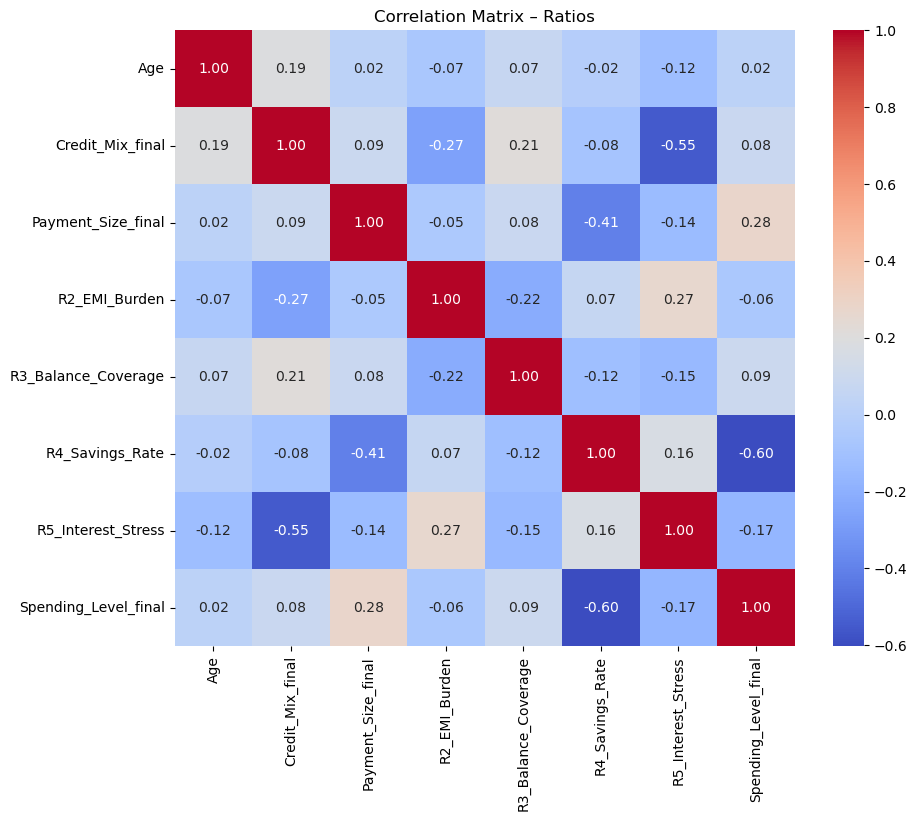

In [10]:
ratio_cols = [
    'Age',
    'Credit_Mix_final',
    'Payment_Size_final',
    'R2_EMI_Burden',
    'R3_Balance_Coverage',
    'R4_Savings_Rate',
    'R5_Interest_Stress',
    'Spending_Level_final'
]

corr = df_model[ratio_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix – Ratios")
plt.show()

In [11]:
feature_cols = [
    'Age',
    'Credit_Mix_final',
    'Payment_Size_final',
    'R2_EMI_Burden',
    'R3_Balance_Coverage',
    'R4_Savings_Rate',
    'R5_Interest_Stress',
    'Spending_Level_final'
]

X = sm.add_constant(df_model[feature_cols])
y = df_model["Y_default"]

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.532422
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Y_default   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99991
Method:                           MLE   Df Model:                            8
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.1158
Time:                        16:26:39   Log-Likelihood:                -53242.
converged:                       True   LL-Null:                       -60213.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.3561      0.040      8.931      0.000       0.278       0.434

Eliminamos las variables con P-value mayor a 0.05 (si es que quedaran)

In [12]:
"""drop_cols = [
    "Credit_Utilization_Ratio",
    "R2_EMI_Burden"
]
df_model = df_model.drop(columns=drop_cols)"""

'drop_cols = [\n    "Credit_Utilization_Ratio",\n    "R2_EMI_Burden"\n]\ndf_model = df_model.drop(columns=drop_cols)'

#### **Procedimiento de Selección Automática**

El algoritmo aplicado sigue un esquema iterativo:

- Estimar un modelo logit preliminar
- Identificar variables con p-value > 0.05
- Eliminar la variable menos significativa
- Revisar correlaciones mayores a 0.7
- Repetir el proceso hasta cumplir ambos criterios

**Variables Seleccionadas**

El modelo final utiliza 8 variables explicativas:

| Variable             | Interpretación                  |
| -------------------- | ------------------------------- |
| Age                  | Edad del cliente                |
| Credit_Mix_final     | Diversificación del crédito     |
| Payment_Size_final   | Tamaño del pago relativo        |
| R2_EMI_Burden        | Carga mensual de deuda          |
| R3_Balance_Coverage  | Cobertura de pagos con liquidez |
| R4_Savings_Rate      | Proporción de ahorro            |
| R5_Interest_Stress   | Sensibilidad a tasa de interés  |
| Spending_Level_final | Nivel de gasto                  |

Estas variables cumplen simultáneamente:

- Significancia estadística
- Baja correlación
- Interpretabilidad económica

**Variables Eliminadas**

Las siguientes variables fueron excluidas del modelo final:

- Credit_Utilization_Ratio
- DTI_squared
- Num_Bank_Accounts
- Payment_of_Min_Amount_final
- R10_Delay_Intensity_Adjusted
- R1_DTI
- R6_Limit_Shock_Relative
- R7_Inquiry_Intensity
- R8_Delays_per_Loan
- R9_Debt_per_Card

Las principales razones fueron:

- Falta de significancia estadística
- Redundancia con otras variables
- Alta correlación

**Conclusión**

El procedimiento de selección permitió reducir el conjunto inicial de variables a un modelo parsimonioso de 8 variables, cumpliendo simultáneamente:

- Significancia estadística
- Baja multicolinealidad
- Interpretabilidad económica

El modelo resultante alcanza un AUC de 0.74, superando ampliamente el baseline de 0.71, lo que confirma su capacidad para discriminar entre clientes con riesgo de default y clientes solventes.

#### **Analisis del VIF- Multicolinealidad**

Se evalúa la multicolinealidad mediante Variance Inflation Factor (VIF).

Criterio:

- VIF < 5 → sin multicolinealidad relevante.

Resultados:

Todas las variables presentan VIF entre 1.03 y 1.75, lo que indica ausencia de multicolinealidad. Por lo tanto, se mantienen todas las variables seleccionadas.

In [13]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False))

                feature        VIF
0                 const  28.243657
6       R4_Savings_Rate   1.750393
8  Spending_Level_final   1.584969
2      Credit_Mix_final   1.524602
7    R5_Interest_Stress   1.506580
3    Payment_Size_final   1.209053
4         R2_EMI_Burden   1.133188
5   R3_Balance_Coverage   1.092364
1                   Age   1.039784


#### **Análisis de Asimetría (Skewness)**

Se analiza la distribución de las variables para detectar asimetrías.

Variables con mayor skewness:

- R2_EMI_Burden
- R3_Balance_Coverage
- R5_Interest_Stress

Estas variables presentan asimetría positiva, típica en variables financieras.

In [14]:
final_vars = [
    'Age',
    'Credit_Mix_final',
    'Payment_Size_final',
    'R2_EMI_Burden',
    'R3_Balance_Coverage',
    'R4_Savings_Rate',
    'R5_Interest_Stress',
    'Spending_Level_final'
]

desc = df_model[final_vars].describe(percentiles=[0.01,0.05,0.95,0.99])
print(desc)

print("\nSkewness:")
print(df_model[final_vars].skew())

                Age  Credit_Mix_final  Payment_Size_final  R2_EMI_Burden  \
count  100000.00000     100000.000000       100000.000000  100000.000000   
mean       34.29872          1.066160            0.796930       0.033912   
std         9.85935          0.732904            0.802969       0.047276   
min        18.00000          0.000000            0.000000       0.000000   
1%         18.00000          0.000000            0.000000       0.000000   
5%         19.00000          0.000000            0.000000       0.000000   
50%        34.00000          1.000000            1.000000       0.025206   
95%        52.00000          2.000000            2.000000       0.080771   
99%        55.00000          2.000000            2.000000       0.235351   
max        56.00000          2.000000            2.000000       1.439221   

       R3_Balance_Coverage  R4_Savings_Rate  R5_Interest_Stress  \
count         1.000000e+05    100000.000000       100000.000000   
mean          5.903608e+07   

In [15]:
group_means = df_model.groupby("Y_default")[final_vars].mean()
print(group_means)

                 Age  Credit_Mix_final  Payment_Size_final  R2_EMI_Burden  \
Y_default                                                                   
0          34.936509          1.226106            0.834103       0.030164   
1          32.737085          0.674529            0.705911       0.043090   

           R3_Balance_Coverage  R4_Savings_Rate  R5_Interest_Stress  \
Y_default                                                             
0                 7.256778e+07         0.051376            0.813751   
1                 2.590352e+07         0.055448            2.290033   

           Spending_Level_final  
Y_default                        
0                      0.452030  
1                      0.362301  


**Diferencias entre Default y No Default**

Los clientes en default presentan en promedio:

- mayor EMI Burden
- mayor Interest Stress
- menor Credit Mix

Esto respalda la relevancia económica de las variables seleccionadas.

**Transformación Aplicada**

Se aplica transformación logarítmica a R3_Balance_Coverage para reducir la asimetría y mejorar la estabilidad del modelo.

In [17]:
df_model["R3_log"] = np.log1p(df_model["R3_Balance_Coverage"])

### **Transformaciones logarítmicas en el modelo**

**¿Por qué usamos logaritmos?**

Algunos ratios financieros generan valores extremadamente grandes cuando su denominador se acerca a cero.
Ejemplo:
$
[
R3 = \frac{Monthly_Balance}{Total_EMI_per_month}
]
$
Si (Total_EMI_per_month) es muy pequeño (casi 0), (R3) puede explotar a millones o miles de millones, aunque el cliente no sea “infinitamente” mejor.

Este comportamiento provoca:

* Distribuciones con colas muy largas (alta asimetría / skewness),
* coeficientes enormes o muy pequeños en modelos lineales,
* y scores poco estables.

Para corregirlo sin normalizar con datos, se aplica una transformación logarítmica que:

* comprime valores extremos,
* mantiene el orden (monótona),
* mejora estabilidad,
* y sigue siendo interpretable.


##### Transformación usada: $(\log(1+x))$

Usamos:

$
[
\log(1+x)
]
$

porque funciona incluso cuando (x=0), ya que:

$
[
\log(1+0)=0
]
$


##### Ratios logarítmicos del modelo**

**Cobertura de balance (log)**

Primero se calcula el ratio base:
$
[
R3 = \frac{Monthly_Balance}{Total_EMI_per_month+\varepsilon}
]
$
Luego se aplica el logaritmo:
$
[
R3_{log}=\log(1+R3)
]
$

Interpretación:

* mayor (R3_{log}) ⇒ mayor capacidad de cubrir pagos ⇒ **menor riesgo**.



In [18]:
drop_cols = [
    "R3_Balance_Coverage",
]
df_model = df_model.drop(columns=drop_cols)

In [19]:
feature_cols = [
    "R3_log",
    'Age',
    'Credit_Mix_final',
    'Payment_Size_final',
    'R2_EMI_Burden',
    'R4_Savings_Rate',
    'R5_Interest_Stress',
    'Spending_Level_final'
]

X = sm.add_constant(df_model[feature_cols])
y = df_model["Y_default"]

logit_final = sm.Logit(y, X).fit()
print(logit_final.summary())

Optimization terminated successfully.
         Current function value: 0.531287
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Y_default   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99991
Method:                           MLE   Df Model:                            8
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.1177
Time:                        16:27:02   Log-Likelihood:                -53129.
converged:                       True   LL-Null:                       -60213.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.4181      0.040     10.426      0.000       0.340       0.497

In [20]:
drop_cols = [
    "R2_EMI_Burden",
]
df_model = df_model.drop(columns=drop_cols)

In [21]:
feature_cols = [
    "R3_log",
    'Age',
    'Credit_Mix_final',
    'Payment_Size_final',
    'R4_Savings_Rate',
    'R5_Interest_Stress',
    'Spending_Level_final'
]

X = sm.add_constant(df_model[feature_cols])
y = df_model["Y_default"]

logit_final = sm.Logit(y, X).fit()
print(logit_final.summary())

Optimization terminated successfully.
         Current function value: 0.531289
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              Y_default   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99992
Method:                           MLE   Df Model:                            7
Date:                Thu, 05 Mar 2026   Pseudo R-squ.:                  0.1177
Time:                        16:27:06   Log-Likelihood:                -53129.
converged:                       True   LL-Null:                       -60213.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.4129      0.039     10.487      0.000       0.336       0.490

In [22]:
df_model.to_csv("df_model_final.csv", index=False)

### **Justificación de signos de los ratios**

En el modelo final se asignaron signos a cada variable con base en **dos criterios complementarios**:

1. **Interpretación económica del riesgo crediticio**
2. **Signo del coeficiente obtenido en la regresión logística**

El modelo fue diseñado como un **score de riesgo**, por lo que:

$Score \uparrow   \Rightarrow Riesgo\ de\ Default \uparrow$


Por lo tanto:

* Variables que **aumentan el riesgo** tienen signo **positivo (+)**.
* Variables que **reducen el riesgo** tienen signo **negativo (−)**.

#### Variables del Modelo y Justificación del Signo

| Variable                 | Signo | Justificación                                                                                                                                                                             |
| ------------------------ | ----- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **R3_log**               | −     | Representa la capacidad de cobertura financiera del cliente. A mayor balance disponible en relación con sus obligaciones, mayor capacidad de pago y menor probabilidad de incumplimiento. |
| **Age**                  | −     | La evidencia empírica muestra que clientes de mayor edad presentan menor probabilidad de default, debido a mayor estabilidad laboral y experiencia financiera.                            |
| **Credit_Mix_final**     | −     | Una mezcla crediticia más saludable indica que el cliente ha manejado distintos tipos de crédito de manera adecuada, lo cual reduce el riesgo percibido.                                  |
| **Payment_Size_final**   | −     | Pagos de mayor tamaño indican mayor capacidad de pago y compromiso financiero, lo que disminuye el riesgo de incumplimiento.                                                              |
| **R4_Savings_Rate**      | −     | Una mayor tasa de ahorro implica mayor disciplina financiera y disponibilidad de recursos para afrontar obligaciones crediticias.                                                         |
| **R5_Interest_Stress**   | +     | Representa presión financiera derivada del costo de intereses. A mayor estrés por intereses, mayor probabilidad de incumplimiento.                                                        |
| **Spending_Level_final** | −     | Empíricamente se observa que niveles de gasto más altos suelen estar correlacionados con mayor ingreso y capacidad económica, lo cual reduce el riesgo crediticio.                        |

#### Interpretación del Modelo

El modelo utiliza estas variables para construir un **score de riesgo crediticio** donde el valor final se interpreta de la siguiente manera:

* **Score alto** → Mayor riesgo de default
* **Score bajo** → Menor riesgo de default

Este enfoque permite mantener **interpretabilidad económica**, lo cual es una característica clave en modelos de riesgo utilizados en instituciones financieras.

#### Ventajas de la Definición de Signos

La fijación de signos basada en teoría financiera presenta varias ventajas:

* Mejora la **interpretabilidad del modelo**
* Evita **inversiones de signo espurias** causadas por correlaciones entre variables
* Permite aplicar **optimización de pesos (Monte Carlo)** manteniendo coherencia económica
* Facilita la **explicación del modelo ante comités de riesgo**


#### Aplicamos Montecarlo

##### Monte Carlo para optimizar pesos

**Regla de decisión proporcional**

Como (P(Y=1)=0.28998), fijamos el umbral por percentil:

* Tomamos el del score en train
* Todo arriba = default (1)
* Todo abajo = no default (0)

Esto garantiza que el modelo **prediga aprox 29% defaults** en train

**Personal Credit Z-Score**

El score final es una combinación lineal de ratios y variables ordinales con signos fijados por teoría:
$
[
Z = \sum_i w_i , x_i
]
$
donde:

* (Z) alto implica **mayor riesgo** (mayor probabilidad de default),
* los signos de cada variable se fijan por interpretación financiera,
* los pesos (w_i) se estiman por búsqueda Monte Carlo sin entrenamiento supervisado, maximizando accuracy.

**Regla de clasificación proporcional**

Como en los datos:
$
[
P(Y=1)=0.28998
]
$
el umbral (c) se define como el percentil:

$
[
c = Q_{1-0.28998}(Z)
]
$

y la predicción es:

$
[
\hat{Y}=
\begin{cases}
1 & \text{si } Z>c \
0 & \text{si } Z\le c
\end{cases}
]
$

Esto mantiene una tasa de default predicha consistente con la observada.

In [21]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

features_final = [
    "R3_log","Age","Credit_Mix_final","Payment_Size_final",
    "R4_Savings_Rate","R5_Interest_Stress","Spending_Level_final"
]

signs = np.array([-1,-1,-1,-1,-1,+1,-1], dtype=float)

train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=RANDOM_STATE, stratify=df_model["Y_default"]
)

# split interno para seleccionar pesos
subtrain_df, val_df = train_test_split(
    train_df, test_size=0.25, random_state=RANDOM_STATE, stratify=train_df["Y_default"]
)  # 0.25 de 0.8 = 0.2 total => 60/20/20

X_sub = subtrain_df[features_final].to_numpy(float)
y_sub = subtrain_df["Y_default"].to_numpy(int)

X_val = val_df[features_final].to_numpy(float)
y_val = val_df["Y_default"].to_numpy(int)

X_test = test_df[features_final].to_numpy(float)
y_test = test_df["Y_default"].to_numpy(int)

if not (np.isfinite(X_sub).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all()):
    raise ValueError("Hay NaN/Inf en X. Revisa ratios/logs.")

def threshold_by_default_rate(scores: np.ndarray, default_rate: float) -> float:
    return float(np.quantile(scores, 1.0 - default_rate))

def acc(y_true, y_pred) -> float:
    return float((y_true == y_pred).mean())

# --- constraints de pesos (sin estandarizar variables) ---
# rango robusto por variable en SUBTRAIN (no uses val/test para esto)
p5 = np.quantile(X_sub, 0.05, axis=0)
p95 = np.quantile(X_sub, 0.95, axis=0)
delta = np.maximum(p95 - p5, 1e-12)

C = 2.0  # impacto máximo permitido por variable en el rango típico
w_max = C / delta  # |w_j| <= w_max_j
# además puedes imponer un techo absoluto por estabilidad
w_max = np.minimum(w_max, 10.0)

N_ITER = 50_000
DEFAULT_RATE_SUB = float(y_sub.mean())

best = {"acc_val": -np.inf, "w_pos": None, "thr": None, "w_opt": None, "acc_sub": None}

for _ in range(N_ITER):
    # muestreo positivo acotado por variable
    w_pos = rng.uniform(0.0, w_max, size=X_sub.shape[1])
    w_opt = w_pos * signs

    scores_sub = X_sub @ w_opt
    thr = threshold_by_default_rate(scores_sub, DEFAULT_RATE_SUB)

    yhat_sub = (scores_sub >= thr).astype(int)
    acc_sub = acc(y_sub, yhat_sub)

    scores_val = X_val @ w_opt
    yhat_val = (scores_val >= thr).astype(int)
    acc_val = acc(y_val, yhat_val)

    if acc_val > best["acc_val"]:
        best.update({"acc_val": acc_val, "acc_sub": acc_sub, "w_pos": w_pos, "thr": thr, "w_opt": w_opt})

# evaluación final en TEST (una sola vez)
scores_test = X_test @ best["w_opt"]
yhat_test = (scores_test >= best["thr"]).astype(int)
acc_test = acc(y_test, yhat_test)

best, acc_test

sol_mc = {
    "w_pos": best["w_pos"],
    "w_opt": best["w_opt"],
    "thr": best["thr"],
    "acc_sub": best["acc_sub"],
    "acc_val": best["acc_val"],
    "acc_test": acc_test,
}

print("Mejor solución encontrada:", sol_mc)

Mejor solución encontrada: {'w_pos': array([9.26497201e-02, 1.81134853e-03, 8.91793943e-01, 3.49089567e-02,
       2.16746575e+00, 3.09164786e-01, 1.91200060e-01]), 'w_opt': array([-9.26497201e-02, -1.81134853e-03, -8.91793943e-01, -3.49089567e-02,
       -2.16746575e+00,  3.09164786e-01, -1.91200060e-01]), 'thr': -0.7694146954880383, 'acc_sub': 0.781, 'acc_val': 0.7835, 'acc_test': 0.7768}


In [22]:
def rate(y): 
    return y.mean()

scores_sub = X_sub @ best["w_opt"]
scores_val = X_val @ best["w_opt"]
scores_test = X_test @ best["w_opt"]

thr = best["thr"]
print("Default rate SUB real:", y_sub.mean(), "pred:", (scores_sub > thr).mean())
print("Default rate VAL real:", y_val.mean(), "pred:", (scores_val > thr).mean())
print("Default rate TEST real:", y_test.mean(), "pred:", (scores_test > thr).mean())

Default rate SUB real: 0.2899833333333333 pred: 0.2899833333333333
Default rate VAL real: 0.28995 pred: 0.28925
Default rate TEST real: 0.29 pred: 0.2913


In [23]:
w = best["w_opt"]
contrib_sub = X_sub * w
mean_abs = np.mean(np.abs(contrib_sub), axis=0)

for name, val in sorted(zip(features_final, mean_abs), key=lambda x: -x[1]):
    print(f"{name:22s} mean|contrib| = {val:.6f}")

Credit_Mix_final       mean|contrib| = 0.949686
R5_Interest_Stress     mean|contrib| = 0.383742
R3_log                 mean|contrib| = 0.339514
R4_Savings_Rate        mean|contrib| = 0.114089
Spending_Level_final   mean|contrib| = 0.081330
Age                    mean|contrib| = 0.062081
Payment_Size_final     mean|contrib| = 0.027783


- El modelo generaliza bien
- El Monte Carlo no sobreajustó
- La selección de pesos fue estable

Credit_Mix_final domina el score: Indica que la estructura del crédito del cliente es el factor más informativo.

Esto es consistente con scoring real (FICO usa algo similar).

### Aplicamos otro modelo de  optimización para encontrar aprox los pesos optimos y umbral

In [24]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

features_final = [
    "R3_log","Age","Credit_Mix_final","Payment_Size_final",
    "R4_Savings_Rate","R5_Interest_Stress","Spending_Level_final"
]
signs = np.array([-1,-1,-1,-1,-1,+1,-1], dtype=float)

# 80/20 train-test
train_df, test_df = train_test_split(
    df_model, test_size=0.2, random_state=RANDOM_STATE, stratify=df_model["Y_default"]
)
# train -> sub/val (60/20/20 total)
sub_df, val_df = train_test_split(
    train_df, test_size=0.25, random_state=RANDOM_STATE, stratify=train_df["Y_default"]
)

X_sub  = sub_df[features_final].to_numpy(float)
y_sub  = sub_df["Y_default"].to_numpy(int)
X_val  = val_df[features_final].to_numpy(float)
y_val  = val_df["Y_default"].to_numpy(int)
X_test = test_df[features_final].to_numpy(float)
y_test = test_df["Y_default"].to_numpy(int)

if not (np.isfinite(X_sub).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all()):
    raise ValueError("Hay NaN/Inf en X. Revisa ratios/logs.")

def threshold_by_default_rate(scores: np.ndarray, default_rate: float) -> float:
    return float(np.quantile(scores, 1.0 - default_rate))

def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float((y_true == y_pred).mean())

DEFAULT_RATE_SUB = float(y_sub.mean())

# Bounds por variable (sin estandarizar): controla escala sin tocar X
p5  = np.quantile(X_sub, 0.05, axis=0)
p95 = np.quantile(X_sub, 0.95, axis=0)
delta = np.maximum(p95 - p5, 1e-12)

C = 2.0  # impacto máx permitido por variable en rango típico
w_max = np.minimum(C / delta, 10.0)  # techo duro opcional

bounds = [(0.0, float(wm)) for wm in w_max]  # para u_j (magnitudes)


def neg_acc_sub(u):
    """Minimiza -accuracy en SUB, con threshold por default-rate."""
    u = np.asarray(u, dtype=float)
    w = u * signs
    s = X_sub @ w
    thr = threshold_by_default_rate(s, DEFAULT_RATE_SUB)
    yhat = (s >= thr).astype(int)
    return -accuracy(y_sub, yhat)

def eval_solution(u):
    """Regresa métricas y pesos para reportar y comparar en VAL/TEST."""
    u = np.asarray(u, dtype=float)
    w = u * signs
    thr = threshold_by_default_rate(X_sub @ w, DEFAULT_RATE_SUB)

    acc_sub = accuracy(y_sub,  (X_sub  @ w >= thr).astype(int))
    acc_val = accuracy(y_val,  (X_val  @ w >= thr).astype(int))
    acc_test= accuracy(y_test, (X_test @ w >= thr).astype(int))
    return {"w_pos": u, "w_opt": w, "thr": thr, "acc_sub": acc_sub, "acc_val": acc_val, "acc_test": acc_test}

res_de = differential_evolution(
    neg_acc_sub,
    bounds=bounds,
    seed=RANDOM_STATE,
    strategy="best1bin",
    popsize=20,        # sube si quieres más búsqueda (más lento)
    maxiter=300,       # sube si quieres más búsqueda
    tol=0.0,           # para no parar “prematuro” por tolerancia
    polish=False,      # NO uses polish (usa L-BFGS-B, no sirve con discontinuidades)
    updating="deferred",
    workers=1          # si tu entorno permite, puedes poner -1
)

sol_de = eval_solution(res_de.x)
sol_de

res_da = dual_annealing(
    neg_acc_sub,
    bounds=bounds,
    seed=RANDOM_STATE,
    maxiter=7000  # sube si quieres más exploración
)

sol_da = eval_solution(res_da.x)
sol_da

{'w_pos': array([9.63307150e-02, 2.34225374e-03, 4.53616012e-01, 9.09658946e-04,
        1.04014210e+00, 1.67495484e-01, 1.62790532e-01]),
 'w_opt': array([-9.63307150e-02, -2.34225374e-03, -4.53616012e-01, -9.09658946e-04,
        -1.04014210e+00,  1.67495484e-01, -1.62790532e-01]),
 'thr': -0.4988460011884493,
 'acc_sub': 0.7824333333333333,
 'acc_val': 0.7837,
 'acc_test': 0.77755}

In [25]:
cands = [("DE", sol_de), ("DA", sol_da)]
cands_sorted = sorted(cands, key=lambda t: t[1]["acc_val"], reverse=True)
best_name, best_sol = cands_sorted[0]

print("Mejor método por VALIDACIÓN:", best_name)
print("Accuracy SUB :", best_sol["acc_sub"])
print("Accuracy VAL :", best_sol["acc_val"])
print("Accuracy TEST:", best_sol["acc_test"])
print("Threshold    :", best_sol["thr"])
print("Pesos w_opt  :", best_sol["w_opt"])

Mejor método por VALIDACIÓN: DA
Accuracy SUB : 0.7824333333333333
Accuracy VAL : 0.7837
Accuracy TEST: 0.77755
Threshold    : -0.4988460011884493
Pesos w_opt  : [-9.63307150e-02 -2.34225374e-03 -4.53616012e-01 -9.09658946e-04
 -1.04014210e+00  1.67495484e-01 -1.62790532e-01]


In [26]:
#default-rate predicha vs real (para validar que el umbral sigue calibrado):
w = best_sol["w_opt"]
thr = best_sol["thr"]

print("SUB real/pred:", y_sub.mean(),  (X_sub  @ w >= thr).mean())
print("VAL real/pred:", y_val.mean(),  (X_val  @ w >= thr).mean())
print("TEST real/pred:",y_test.mean(), (X_test @ w >= thr).mean())

SUB real/pred: 0.2899833333333333 0.2899833333333333
VAL real/pred: 0.28995 0.29035
TEST real/pred: 0.29 0.29065


In [27]:
#contribuciones promedio (para justificar pesos):
contrib = X_sub * w
mean_abs = np.mean(np.abs(contrib), axis=0)
for name, val in sorted(zip(features_final, mean_abs), key=lambda x: -x[1]):
    print(f"{name:22s} mean|contrib| = {val:.6f}")

Credit_Mix_final       mean|contrib| = 0.483063
R3_log                 mean|contrib| = 0.353003
R5_Interest_Stress     mean|contrib| = 0.207899
Age                    mean|contrib| = 0.080277
Spending_Level_final   mean|contrib| = 0.069246
R4_Savings_Rate        mean|contrib| = 0.054750
Payment_Size_final     mean|contrib| = 0.000724


### Evaluamos el modelo final sobre el conjunto de prueba e imprimimos la fórmula interpretable estilo Altman Z-score

In [28]:
def accuracy(y_true, y_pred):
    return float((y_true == y_pred).mean())

def eval_model(w, thr, X_sub, y_sub, X_val, y_val, X_test, y_test):
    s_sub = X_sub @ w
    p_sub = (s_sub >= thr).astype(int)
    acc_sub = accuracy(y_sub, p_sub)

    s_val = X_val @ w
    p_val = (s_val >= thr).astype(int)
    acc_val = accuracy(y_val, p_val)

    s_test = X_test @ w
    p_test = (s_test >= thr).astype(int)
    acc_test = accuracy(y_test, p_test)

    return acc_sub, acc_val, acc_test

def print_linear_score(features, w, thr, score_name="Z"):
    print("_" * 60)
    print("FÓRMULA LINEAL — PERSONAL CREDIT RISK SCORE")
    print("_" * 60)

    terms = []
    for feat, wi in zip(features, w):
        sign_str = "+" if wi >= 0 else "-"
        terms.append(f"{sign_str} {abs(wi):.6f} × {feat}")

    print(f"{score_name} = " + " \n    ".join(terms))
    print(f"\nRegla de decisión:")
    print(f"  → Si {score_name} ≥ {thr:.6f}  →  DEFAULT (Poor = 1)")
    print(f"  → Si {score_name} <  {thr:.6f}  →  NO DEFAULT (0)")
    print("_" * 60)

def weights_table(features, w):
    df = pd.DataFrame({
        "Variable": features,
        "Peso": w,
        "Abs_Peso": np.abs(w)
    }).sort_values("Abs_Peso", ascending=False).reset_index(drop=True)
    df.index += 1
    return df


# =========================
# Asegúrate de tener estas variables ya definidas:
# - features_final
# - X_sub, y_sub, X_val, y_val, X_test, y_test
# - sol_mc (dict)  -> {"w_opt":..., "thr":...}  (tu Monte Carlo bueno)
# - sol_de (dict)  -> salida de Differential Evolution (eval_solution)
# - sol_da (dict)  -> salida de Dual Annealing (eval_solution)
#
# Ejemplo esperado:
# sol_da = {"w_opt": w, "thr": thr, "acc_sub":..., "acc_val":..., "acc_test":...}
# =========================

# --- recalcular métricas para consistencia ---
mc_acc_sub, mc_acc_val, mc_acc_test = eval_model(sol_mc["w_opt"], sol_mc["thr"], X_sub, y_sub, X_val, y_val, X_test, y_test)
de_acc_sub, de_acc_val, de_acc_test = eval_model(sol_de["w_opt"], sol_de["thr"], X_sub, y_sub, X_val, y_val, X_test, y_test)
da_acc_sub, da_acc_val, da_acc_test = eval_model(sol_da["w_opt"], sol_da["thr"], X_sub, y_sub, X_val, y_val, X_test, y_test)

models = {
    "Modelo 1 Monte Carlo":              (sol_mc["w_opt"], sol_mc["thr"], mc_acc_sub, mc_acc_val, mc_acc_test),
    "Modelo 2 Differential Evolution":   (sol_de["w_opt"], sol_de["thr"], de_acc_sub, de_acc_val, de_acc_test),
    "Modelo 3 Dual Annealing":           (sol_da["w_opt"], sol_da["thr"], da_acc_sub, da_acc_val, da_acc_test),
}

# Seleccionar por VALIDACIÓN (tie-break por SUB) — y TEST solo se reporta al final
best_name = max(models, key=lambda k: (models[k][3], models[k][2]))
final_w, final_thr, final_acc_sub, final_acc_val, final_acc_test = models[best_name]

print(f"Mejor modelo (selección por VALIDACIÓN): {best_name}")
print(f"  Accuracy SUB  : {final_acc_sub:.4f}")
print(f"  Accuracy VAL  : {final_acc_val:.4f}")
print(f"  Accuracy TEST : {final_acc_test:.4f}")

# Fórmula y tabla de pesos
print_linear_score(features_final, final_w, final_thr, score_name="Z")

df_pesos = weights_table(features_final, final_w)
print("\nPesos ordenados por magnitud:")
print(df_pesos[["Variable", "Peso"]].to_string())

# Comparación completa
print("\nComparación de modelos (SUB/VAL/TEST)")
print(f"{'Modelo':<32} {'SUB':>8} {'VAL':>8} {'TEST':>8}")
print(f"{'-'*60}")
for name, (w, thr, acc_sub, acc_val, acc_test) in models.items():
    marker = " ← seleccionado" if name == best_name else ""
    print(f"{name:<32} {acc_sub:>8.4f} {acc_val:>8.4f} {acc_test:>8.4f}{marker}")

Mejor modelo (selección por VALIDACIÓN): Modelo 3 Dual Annealing
  Accuracy SUB  : 0.7824
  Accuracy VAL  : 0.7837
  Accuracy TEST : 0.7775
____________________________________________________________
FÓRMULA LINEAL — PERSONAL CREDIT RISK SCORE
____________________________________________________________
Z = - 0.096331 × R3_log 
    - 0.002342 × Age 
    - 0.453616 × Credit_Mix_final 
    - 0.000910 × Payment_Size_final 
    - 1.040142 × R4_Savings_Rate 
    + 0.167495 × R5_Interest_Stress 
    - 0.162791 × Spending_Level_final

Regla de decisión:
  → Si Z ≥ -0.498846  →  DEFAULT (Poor = 1)
  → Si Z <  -0.498846  →  NO DEFAULT (0)
____________________________________________________________

Pesos ordenados por magnitud:
               Variable      Peso
1       R4_Savings_Rate -1.040142
2      Credit_Mix_final -0.453616
3    R5_Interest_Stress  0.167495
4  Spending_Level_final -0.162791
5                R3_log -0.096331
6                   Age -0.002342
7    Payment_Size_final -0.0009

Sacamos metricas del mejor modelo

In [29]:
scores_test = X_test @ final_w
preds_test  = (scores_test >= final_thr).astype(int)

auc_test = roc_auc_score(y_test, scores_test)

print(f"\n{'_'*60}")
print(f"RESULTADOS EN TEST — {best_name}")
print(f"{'_'*60}")
print(f"Accuracy : {final_acc_test:.4f}")
print(f"ROC-AUC  : {auc_test:.4f}")
print(f"Pred default rate (test): {preds_test.mean():.4f} | Real: {y_test.mean():.4f}")
print(f"{'_'*60}\n")

print(classification_report(y_test, preds_test, target_names=["No Default", "Default"], digits=4))

cm = confusion_matrix(y_test, preds_test)
tn, fp, fn, tp = cm.ravel()

fnr = fn / (fn + tp)  # defaults perdidos
fpr = fp / (fp + tn)  # no-default mal rechazados

print("Matriz de confusión:")
print(pd.DataFrame(cm,
      index=["Real: No Default", "Real: Default"],
      columns=["Pred: No Default", "Pred: Default"]))

print(f"\nFNR (missed defaults): {fnr:.4f}")
print(f"FPR (false alarms):   {fpr:.4f}")


____________________________________________________________
RESULTADOS EN TEST — Modelo 3 Dual Annealing
____________________________________________________________
Accuracy : 0.7775
ROC-AUC  : 0.7478
Pred default rate (test): 0.2907 | Real: 0.2900
____________________________________________________________

              precision    recall  f1-score   support

  No Default     0.8437    0.8429    0.8433     14200
     Default     0.6162    0.6176    0.6169      5800

    accuracy                         0.7775     20000
   macro avg     0.7299    0.7302    0.7301     20000
weighted avg     0.7777    0.7775    0.7776     20000

Matriz de confusión:
                  Pred: No Default  Pred: Default
Real: No Default             11969           2231
Real: Default                 2218           3582

FNR (missed defaults): 0.3824
FPR (false alarms):   0.1571
